<a href="https://colab.research.google.com/github/thaoly-corner/weather_features/blob/develop/notebooks/dev/00_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
pd.set_option('display.max_columns', None)          # Show all columns
pd.set_option('display.width', None)                # Adjust width dynamically
pd.set_option('display.expand_frame_repr', False)   # Prevent column wrapping
warnings.filterwarnings('ignore')

# Get Dataset


In [ ]:
# Install the kagglehub library
!pip install --upgrade kagglehub -q

In [ ]:
import kagglehub
import os

# Dowload dataset
path = kagglehub.dataset_download("PROPPG-PPG/hourly-weather-surface-brazil-southeast-region")

# Create the link to file csv
file_path = os.path.join(path, "north.csv")
print(file_path)

Using Colab cache for faster access to the 'hourly-weather-surface-brazil-southeast-region' dataset.
/kaggle/input/hourly-weather-surface-brazil-southeast-region/north.csv


# Data Exploration

In [ ]:
df = pd.read_csv(file_path)
df.head()

,index,Data,Hora,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",region,state,station,station_code,latitude,longitude,height
0,0,2000-05-09,00:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
1,1,2000-05-09,01:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
2,2,2000-05-09,02:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
3,3,2000-05-09,03:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25
4,4,2000-05-09,04:00,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999,-9999.0,-9999.0,N,AM,MANAUS,A101,-3.103333,-60.016389,61.25


In [ ]:
# 1. Thông tin tổng quan về kiểu dữ liệu và số lượng dòng
print("--- Data Info ---")
df.info()

# 2. Tóm tắt các đại lượng thống kê (Mean, Median, Quartiles, Min, Max)
print("\n--- Data Summarization ---")
display(df.describe())

# 3. Hiển thị thống kê các cột thiếu giá trị
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8392320 entries, 0 to 8392319
Data columns (total 27 columns):
 #   Column                                                 Dtype  
---  ------                                                 -----  
 0   index                                                  int64  
 1   Data                                                   object 
 2   Hora                                                   object 
 3   PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                       float64
 4   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  float64
 5   PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)        float64
 6   PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)       float64
 7   RADIACAO GLOBAL (Kj/m²)                                int64  
 8   TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)           float64
 9   TEMPERATURA DO PONTO DE ORVALHO (°C)                   float64
 10  TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)      

,index,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",latitude,longitude,height
count,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06,8.392320e+06
mean,1.728984e+05,-2.368686e+03,-1.091195e+03,-1.099674e+03,-1.100162e+03,-4.753662e+03,-1.826682e+03,-2.016026e+03,-1.834738e+03,-1.835557e+03,-2.024679e+03,-2.027631e+03,-1.971403e+03,-1.980950e+03,-1.972319e+03,-2.082307e+03,-2.154196e+03,-2.141020e+03,-5.747661e+00,-5.533825e+01,-1.685074e+02
std,1.167873e+05,4.251535e+03,4.308733e+03,4.315761e+03,4.315489e+03,5.871869e+03,3.891501e+03,4.032835e+03,3.898670e+03,3.898081e+03,4.039704e+03,4.040888e+03,4.057146e+03,4.058819e+03,4.055221e+03,4.207228e+03,4.114295e+03,4.102944e+03,3.982830e+00,7.705193e+00,1.812283e+03
min,0.000000e+00,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-1.275056e+01,-7.278667e+01,-9.999000e+03
25%,6.913500e+04,0.000000e+00,9.744000e+02,9.745000e+02,9.738000e+02,-9.999000e+03,2.210000e+01,1.490000e+01,2.240000e+01,2.180000e+01,1.550000e+01,1.410000e+01,4.600000e+01,3.900000e+01,4.200000e+01,1.300000e+01,0.000000e+00,0.000000e+00,-8.968611e+00,-6.062833e+01,5.500000e+01
50%,1.593680e+05,0.000000e+00,9.915000e+02,9.917000e+02,9.911000e+02,-9.999000e+03,2.470000e+01,2.160000e+01,2.510000e+01,2.430000e+01,2.200000e+01,2.110000e+01,7.800000e+01,7.000000e+01,7.400000e+01,8.900000e+01,2.200000e+00,6.000000e-01,-5.365833e+00,-5.186250e+01,1.110000e+02
75%,2.688480e+05,0.000000e+00,1.004000e+03,1.004300e+03,1.003700e+03,9.530000e+02,2.810000e+01,2.290000e+01,2.900000e+01,2.730000e+01,2.330000e+01,2.250000e+01,9.100000e+01,8.800000e+01,9.000000e+01,2.030000e+02,4.500000e+00,1.700000e+00,-2.640556e+00,-4.847861e+01,2.200000e+02
max,4.203920e+05,9.720000e+01,1.050000e+03,1.049800e+03,1.050000e+03,4.530500e+04,4.220000e+01,4.350000e+01,4.500000e+01,4.500000e+01,4.440000e+01,3.980000e+01,1.000000e+02,1.000000e+02,1.000000e+02,3.600000e+02,9.970000e+01,1.990000e+01,4.477500e+00,-4.592000e+01,7.980000e+02


,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# PHẦN 1: TIỀN XỬ LÝ TOÀN BỘ 27 CỘT
# ==============================================================================
print("--- BẮT ĐẦU QUY TRÌNH EDA TOÀN DIỆN CHO 27 CỘT ---")

# 1. Chuyển đổi mã lỗi -9999 thành NaN
df.replace(-9999.0, np.nan, inplace=True)
df.replace(-9999, np.nan, inplace=True)

# 2. Đổi tên toàn bộ 27 cột sang tiếng Anh
full_rename_dict = {
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'Precipitation',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'Pressure',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'Pressure_Max',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'Pressure_Min',
    'RADIACAO GLOBAL (Kj/m²)': 'Solar_Radiation',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'Temperature',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'Dew_Point',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'Temperature_Max',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'Temperature_Min',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'Dew_Point_Max',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'Dew_Point_Min',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'Humidity_Max',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'Humidity_Min',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'Humidity',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'Wind_Direction',
    'VENTO, RAJADA MAXIMA (m/s)': 'Wind_Gust',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'Wind_Speed'
}
df.rename(columns=full_rename_dict, inplace=True)

# 3. Tạo biến mục tiêu (Target Variable)
df['Rain'] = (df['Precipitation'] > 0).astype(int)

# 4. Gom Date và Time thành Datetime Index
df['Datetime'] = pd.to_datetime(df['Data'] + ' ' + df['Hora'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Data', 'Hora', 'index'], inplace=True, errors='ignore')

# 5. Phân nhóm cột & Lọc 1 Trạm (A101) để phân tích chuỗi thời gian
core_features = ['Temperature', 'Humidity', 'Wind_Speed', 'Pressure', 'Dew_Point', 'Solar_Radiation']
statistical_features = [col for col in df.columns if col.endswith('_Max') or col.endswith('_Min')]
metadata_features = ['region', 'state', 'station', 'station_code', 'latitude', 'longitude', 'height']

df_station = df[df['station_code'] == 'A101'].copy()

--- BẮT ĐẦU QUY TRÌNH EDA TOÀN DIỆN CHO 27 CỘT ---



--- BẮT ĐẦU VẼ BIỂU ĐỒ ---


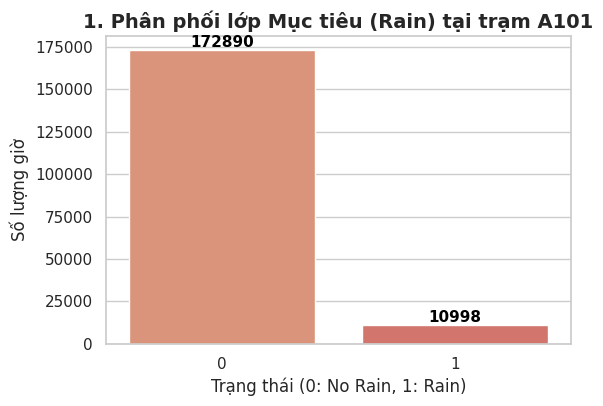

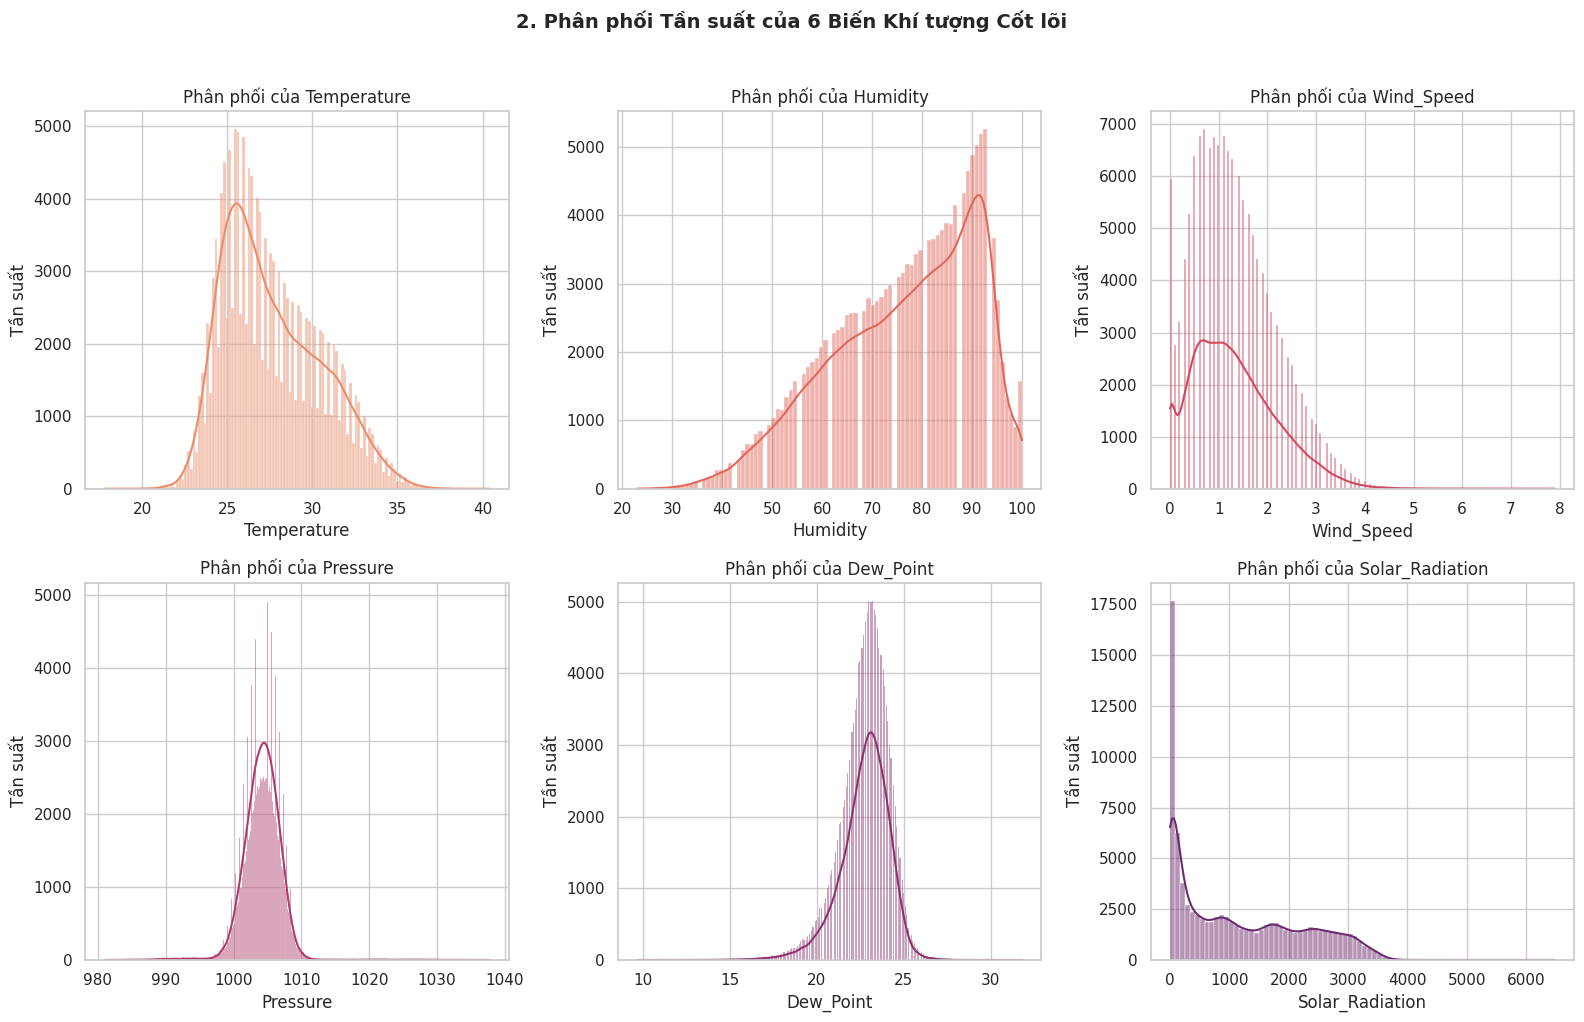

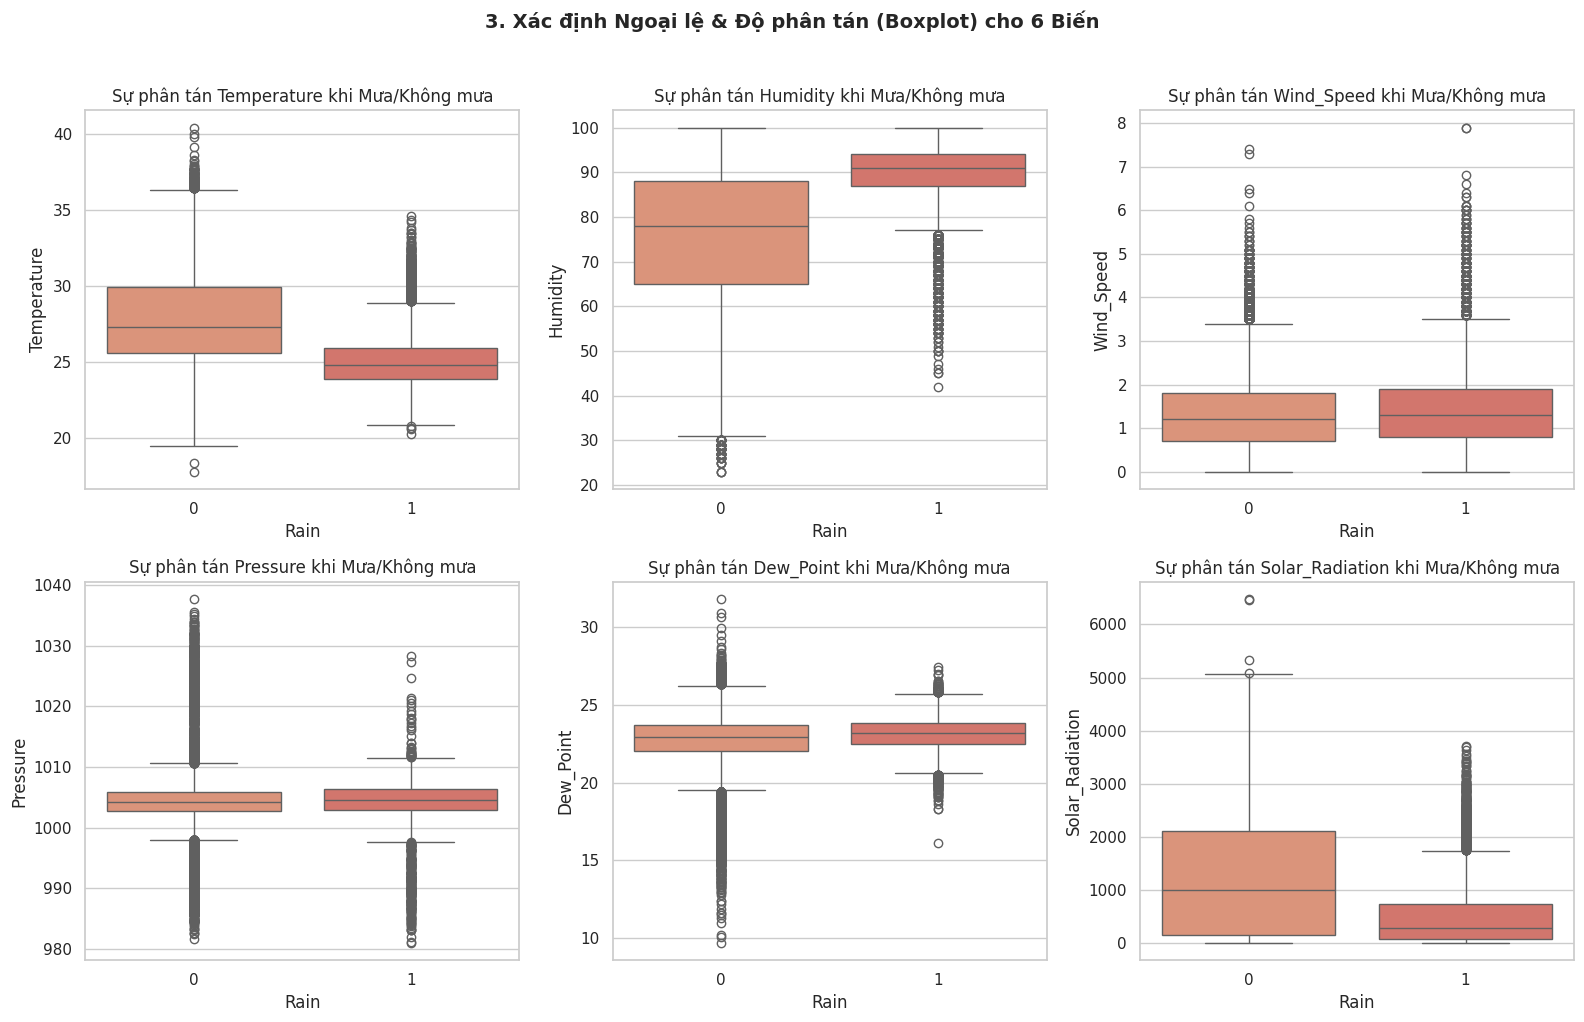

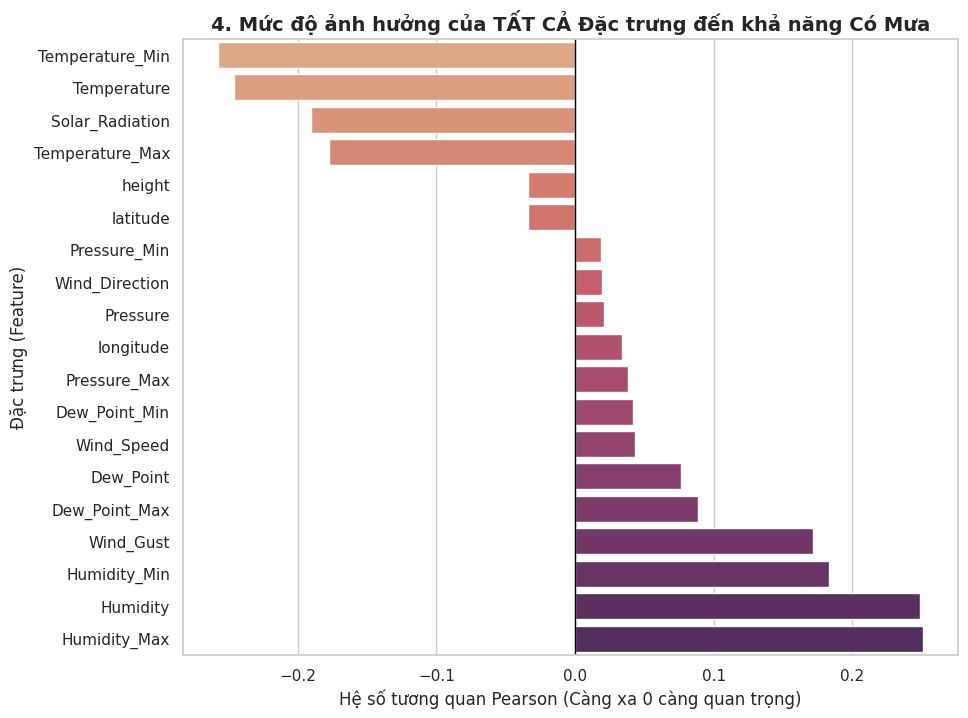

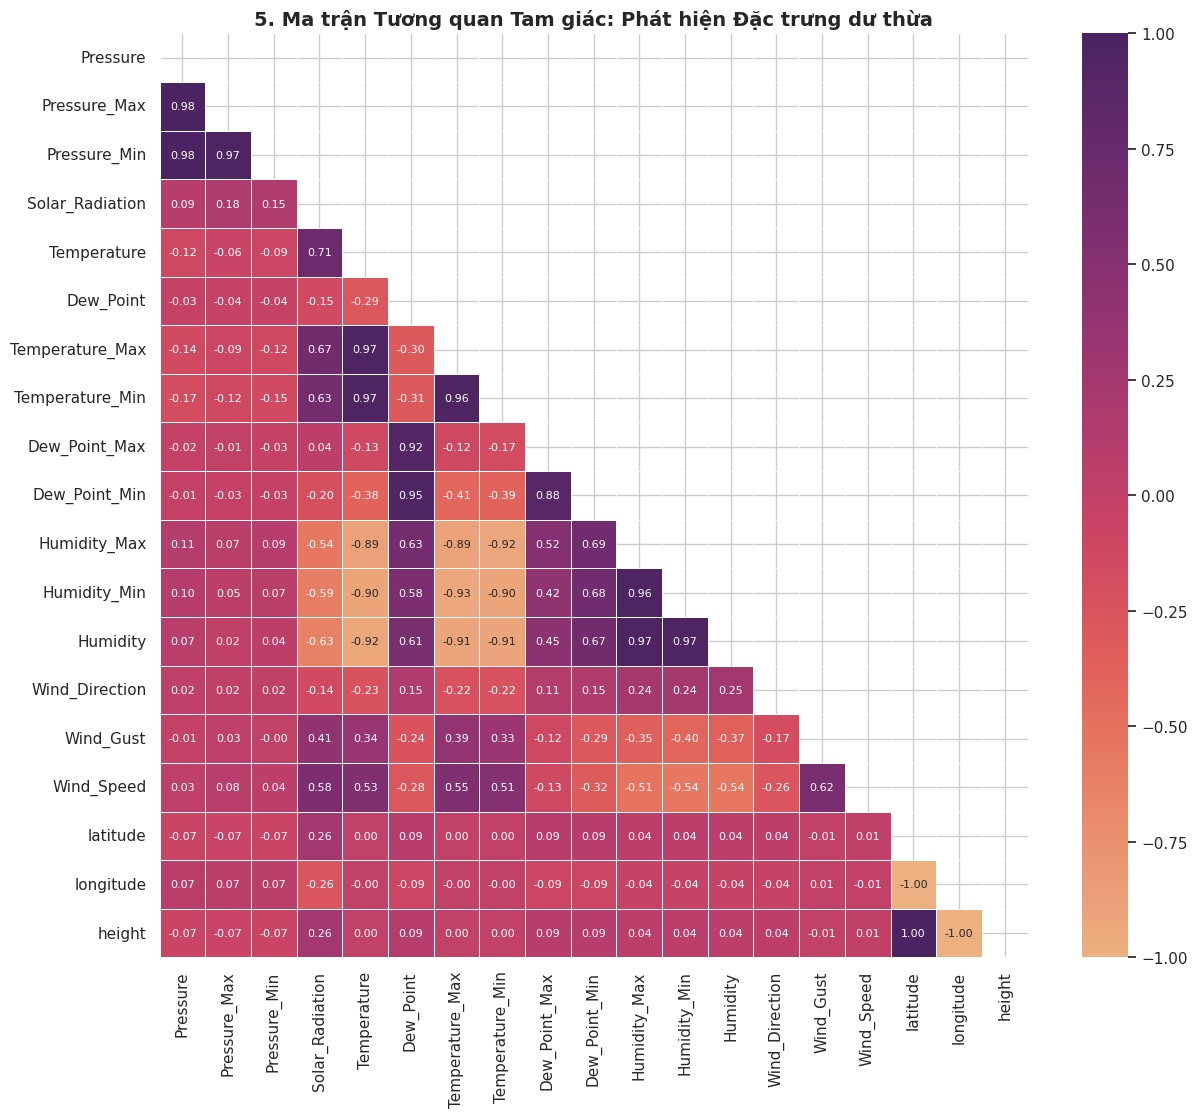

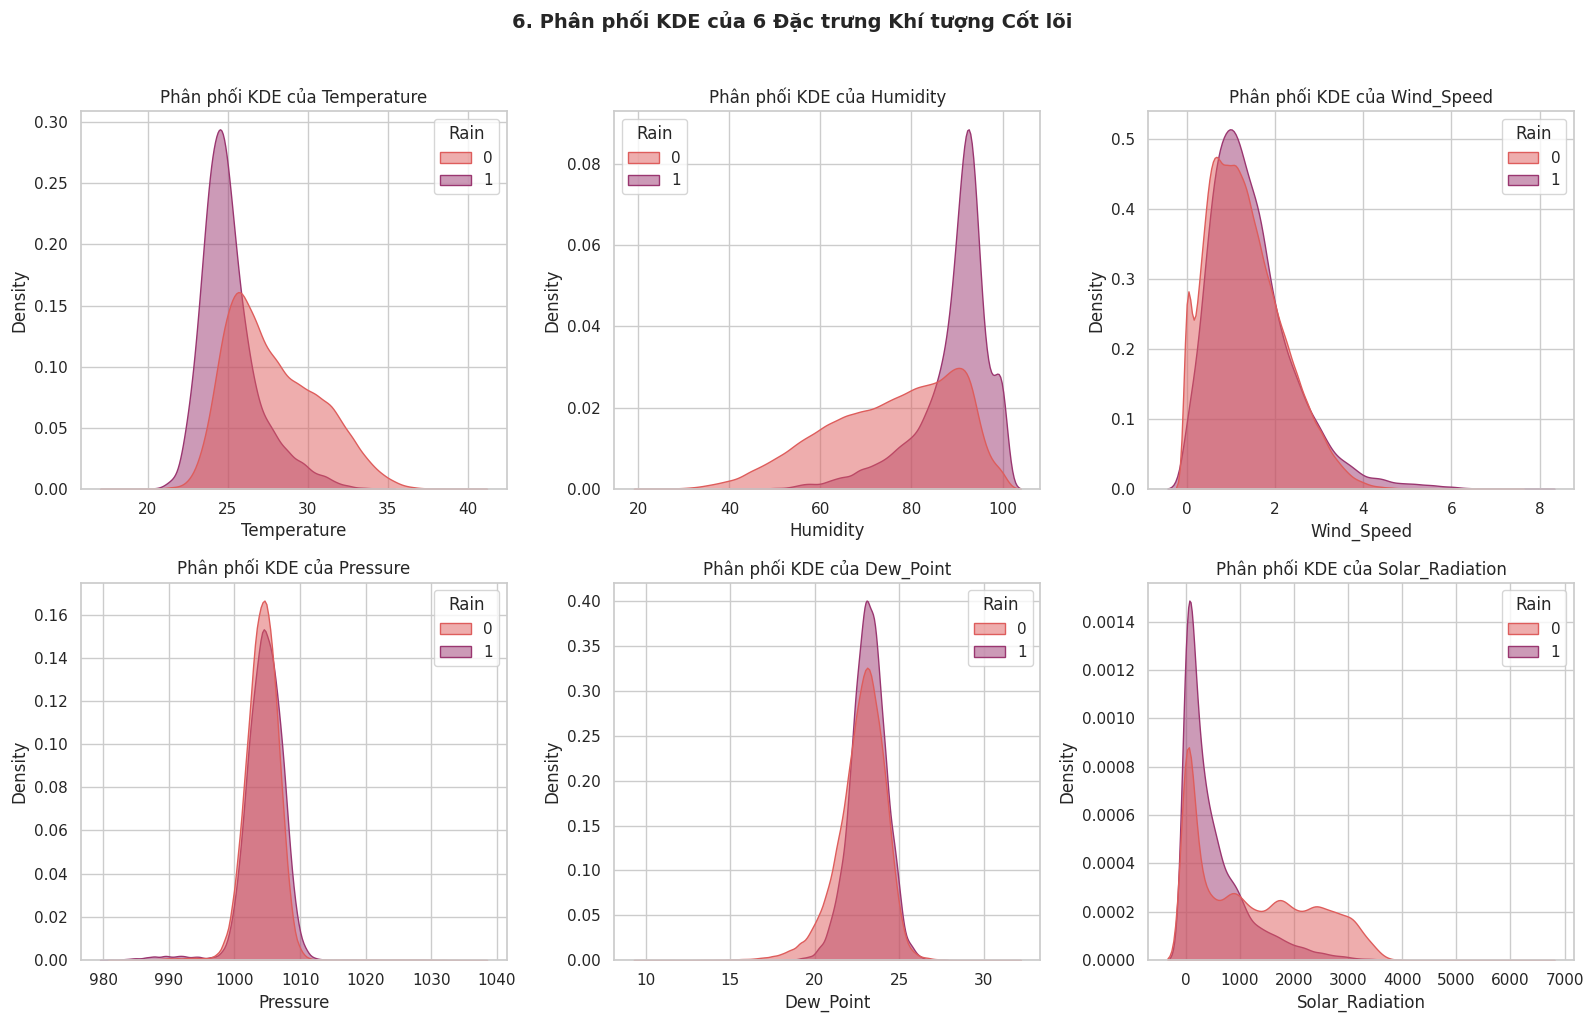


Đang vẽ biểu đồ Chuỗi thời gian cho 4 biến... (Có thể mất một chút thời gian)


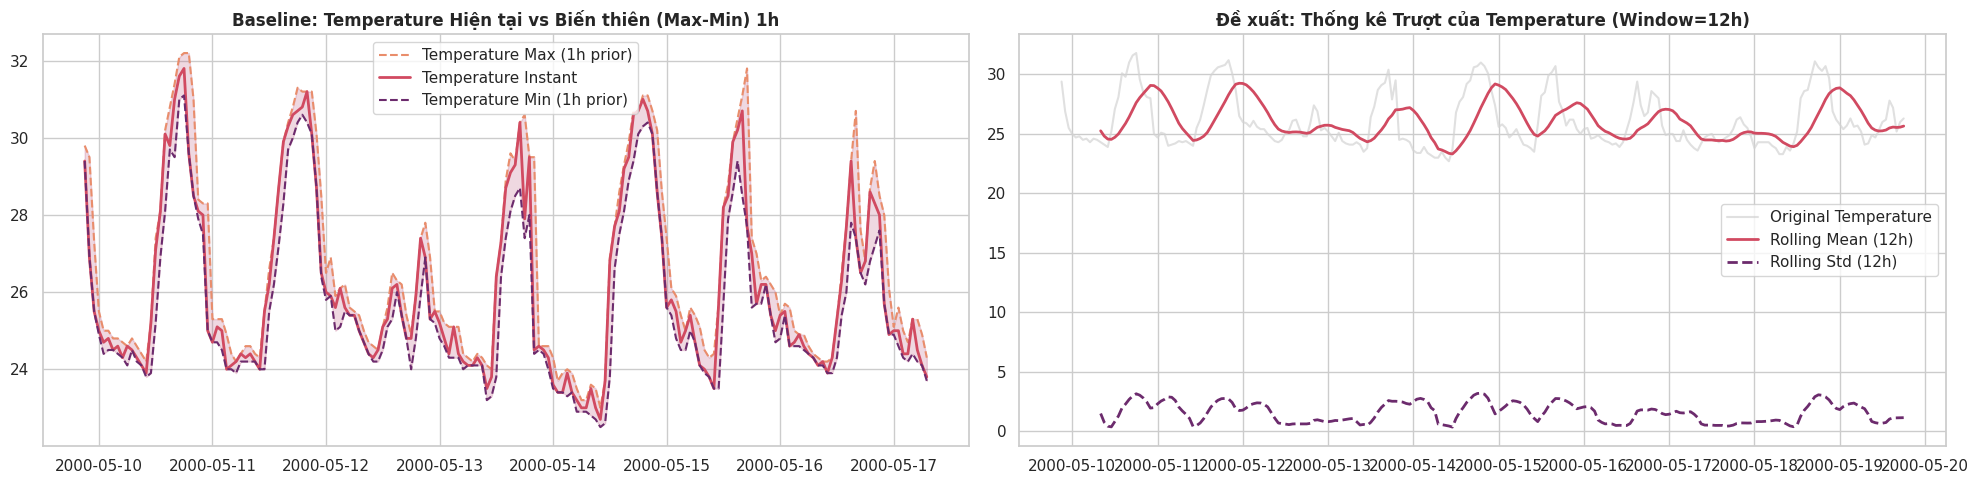

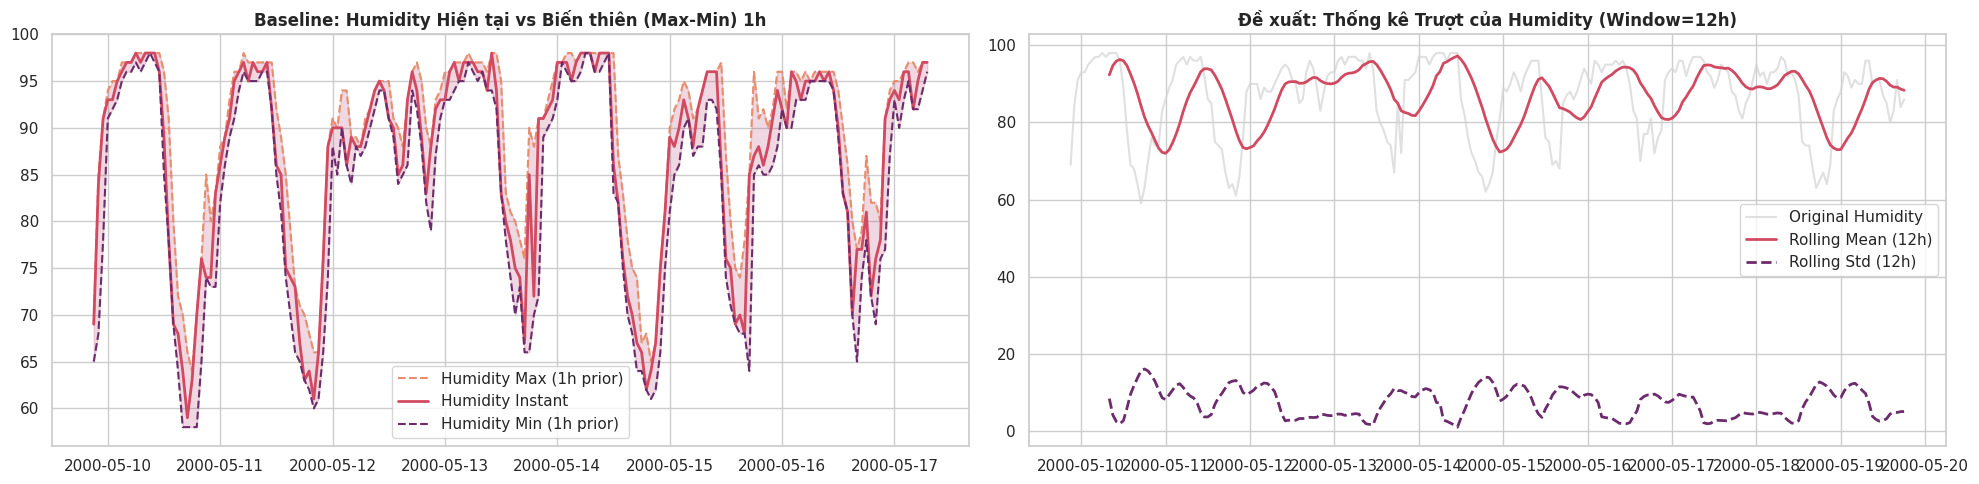

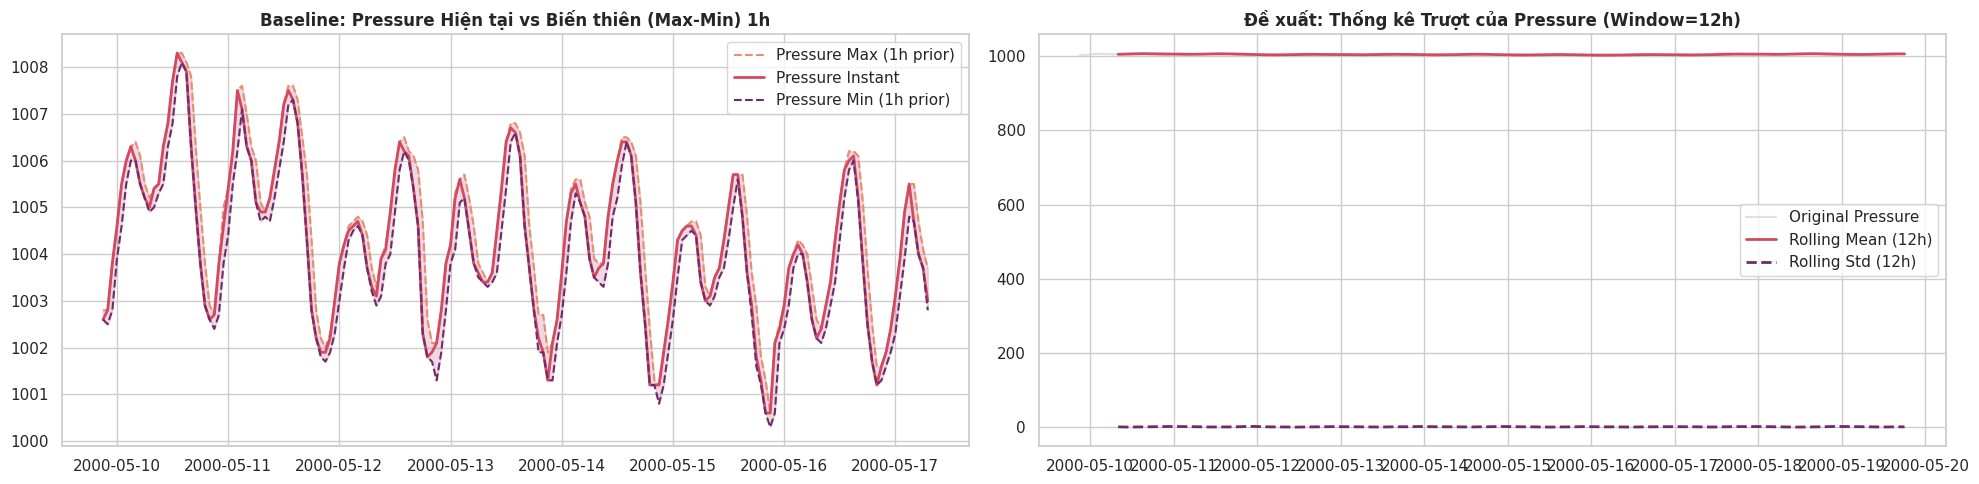

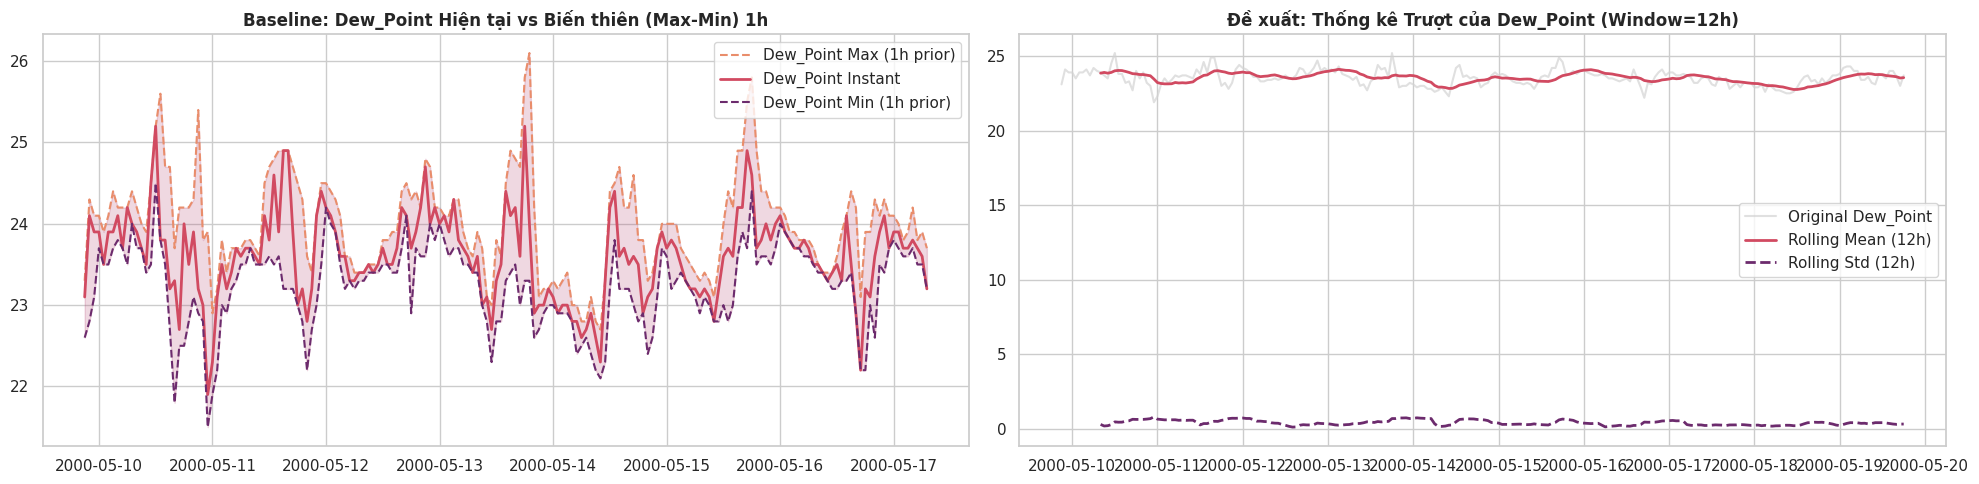

In [ ]:
# ==============================================================================
# PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA TRỰC QUAN - THEME FLARE)
# ==============================================================================
sns.set_theme(style="whitegrid")
warm_palette = sns.color_palette("flare")
heat_cmap = sns.color_palette("flare", as_cmap=True)

print("\n--- BẮT ĐẦU VẼ BIỂU ĐỒ ---")

# ------------------------------------------------------------------------------
# 1. Phân phối lớp Mục tiêu (Có ghi số lượng)
# ------------------------------------------------------------------------------
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_station, x='Rain', palette=warm_palette)
plt.title('1. Phân phối lớp Mục tiêu (Rain) tại trạm A101', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái (0: No Rain, 1: Rain)')
plt.ylabel('Số lượng giờ')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()


# ------------------------------------------------------------------------------
# 2. Phân phối của 6 biến số học cốt lõi (Histogram) - ĐÃ SỬA THÀNH LƯỚI 2x3
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10)) # Thay đổi thành 2 hàng 3 cột
axes = axes.flatten()
for i, col in enumerate(core_features):
    sns.histplot(df_station[col].dropna(), kde=True, ax=axes[i], color=warm_palette[i % len(warm_palette)])
    axes[i].set_title(f'Phân phối của {col}', fontsize=12)
    axes[i].set_ylabel('Tần suất')
plt.suptitle("2. Phân phối Tần suất của 6 Biến Khí tượng Cốt lõi", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. Kiểm tra Ngoại lệ & Độ phân tán (Boxplot) - ĐÃ SỬA THÀNH LƯỚI 2x3
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10)) # Thay đổi thành 2 hàng 3 cột
axes = axes.flatten()
for i, col in enumerate(core_features):
    sns.boxplot(x='Rain', y=col, data=df_station, ax=axes[i], palette=warm_palette)
    axes[i].set_title(f'Sự phân tán {col} khi Mưa/Không mưa', fontsize=12)
plt.suptitle("3. Xác định Ngoại lệ & Độ phân tán (Boxplot) cho 6 Biến", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# CHUẨN BỊ CHO BƯỚC 4 & 5: TÍNH TƯƠNG QUAN TRÊN TẤT CẢ CÁC BIẾN SỐ
# ------------------------------------------------------------------------------
numeric_cols = df_station.select_dtypes(include=['float64', 'int64']).columns.tolist()
features_to_analyze = [col for col in numeric_cols if col not in ['Precipitation', 'Rain']]
corr_with_target = df_station[features_to_analyze + ['Rain']].corr()['Rain'].drop('Rain').sort_values()

# ------------------------------------------------------------------------------
# 4. Tìm ra "Ngôi Sao" (Barplot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="flare")
plt.title("4. Mức độ ảnh hưởng của TẤT CẢ Đặc trưng đến khả năng Có Mưa", fontsize=14, fontweight='bold')
plt.xlabel("Hệ số tương quan Pearson (Càng xa 0 càng quan trọng)")
plt.ylabel("Đặc trưng (Feature)")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

# ------------------------------------------------------------------------------
# 5. Phát hiện Dư thừa dữ liệu (Triangular Heatmap)
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 12))
corr_matrix = df_station[features_to_analyze].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=heat_cmap, fmt=".2f",
            linewidths=.5, vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("5. Ma trận Tương quan Tam giác: Phát hiện Đặc trưng dư thừa", fontsize=14, fontweight='bold')
plt.show()

# ------------------------------------------------------------------------------
# 6. Kiểm tra phân phối của 6 Biến Cốt lõi (KDE Plot)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(core_features):
    # Lọc bỏ NaN để biểu đồ KDE không bị lỗi nội suy
    clean_data = df_station.dropna(subset=[col, 'Rain'])

    sns.kdeplot(data=clean_data, x=col, hue='Rain', fill=True, common_norm=False,
                palette="flare", ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Phân phối KDE của {col}', fontsize=12)

plt.suptitle("6. Phân phối KDE của 6 Đặc trưng Khí tượng Cốt lõi", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 7. Phân tích Cửa sổ thời gian (Baseline Max/Min vs Rolling Window)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 7. Phân tích Cửa sổ thời gian (Baseline Max/Min vs Rolling Window) - CHO 4 BIẾN
# ------------------------------------------------------------------------------
# Chỉ chọn 4 biến thực sự có cột _Max và _Min trong dữ liệu INMET
time_series_features = ['Temperature', 'Humidity', 'Pressure', 'Dew_Point']
window_size = 12

print("\nĐang vẽ biểu đồ Chuỗi thời gian cho 4 biến... (Có thể mất một chút thời gian)")

for col in time_series_features:
    col_max = f"{col}_Max"
    col_min = f"{col}_Min"

    # Tạo Figure chứa 2 biểu đồ (7A và 7B) nằm cạnh nhau cho mỗi biến
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    # Lọc bỏ NaN để biểu đồ không bị đứt gãy
    subset_df = df_station.head(200).dropna(subset=[col, col_max, col_min])

    # Plot 7A: Baseline (Dữ liệu 1h của Trạm)
    axes[0].plot(subset_df.index, subset_df[col_max], label=f'{col} Max (1h prior)', color=warm_palette[0], linestyle='--')
    axes[0].plot(subset_df.index, subset_df[col], label=f'{col} Instant', color=warm_palette[2], linewidth=2)
    axes[0].plot(subset_df.index, subset_df[col_min], label=f'{col} Min (1h prior)', color=warm_palette[5], linestyle='--')
    axes[0].fill_between(subset_df.index, subset_df[col_min], subset_df[col_max], color=warm_palette[3], alpha=0.2)
    axes[0].set_title(f"Baseline: {col} Hiện tại vs Biến thiên (Max-Min) 1h", fontsize=12, fontweight='bold')
    axes[0].legend()

    # Plot 7B: Rolling Window Demo
    subset_rolling = df_station.head(300)
    rolling_mean = subset_rolling[col].rolling(window=window_size).mean()
    rolling_std = subset_rolling[col].rolling(window=window_size).std()

    axes[1].plot(subset_rolling.index, subset_rolling[col], label=f'Original {col}', color='lightgray', alpha=0.7)
    axes[1].plot(subset_rolling.index, rolling_mean, label=f'Rolling Mean ({window_size}h)', color=warm_palette[2], linewidth=2)
    axes[1].plot(subset_rolling.index, rolling_std, label=f'Rolling Std ({window_size}h)', color=warm_palette[5], linewidth=2, linestyle='--')
    axes[1].set_title(f"Đề xuất: Thống kê Trượt của {col} (Window={window_size}h)", fontsize=12, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("--- BẮT ĐẦU QUY TRÌNH DATA PREPROCESSING THEO CHUẨN KDD ---")

# ==============================================================================
# BƯỚC 1: DATA CLEANSING (Làm sạch & Nội suy Missing Data)
# Căn cứ: Giải quyết dữ liệu thiếu bằng phương pháp cập nhật tự động [cite: 243-251]
# ==============================================================================
df_clean = df_station.copy()

# Chọn các biến số học cần nội suy (loại bỏ biến dạng chuỗi/metadata)
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Nội suy tuyến tính theo thời gian (Time-series interpolation) cho dữ liệu bị thiếu
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='time')

# Điền các giá trị NaN ở biên (nếu có) bằng Forward Fill / Backward Fill
df_clean[numeric_cols] = df_clean[numeric_cols].ffill().bfill()

print("1. Đã hoàn thành Data Cleansing: Xử lý dữ liệu thiếu bằng Nội suy.")

--- BẮT ĐẦU QUY TRÌNH DATA PREPROCESSING THEO CHUẨN KDD ---
1. Đã hoàn thành Data Cleansing: Xử lý dữ liệu thiếu bằng Nội suy.


In [ ]:
# ==============================================================================
# BƯỚC 2: DATA TRANSFORMATION - NORMALIZATION (Chuẩn hóa dữ liệu)
# ==============================================================================
scaler = StandardScaler()

# Cột 'Rain' là biến mục tiêu (0 và 1), không được chuẩn hóa.
# Cột 'Precipitation' cũng tạm thời không chuẩn hóa vì ta sẽ bỏ nó.
features_to_scale = [col for col in numeric_cols if col not in ['Rain', 'Precipitation']]

# Áp dụng công thức Z-score
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

print("2. Đã hoàn thành Data Transformation: Chuẩn hóa Z-score.")

2. Đã hoàn thành Data Transformation: Chuẩn hóa Z-score.


In [ ]:
# ==============================================================================
# BƯỚC 3: DATA REDUCTION (Giảm chiều dữ liệu - Lựa chọn tập thuộc tính)
# Căn cứ: Attribute subset selection - Loại bỏ các thuộc tính dư thừa/không liên quan
# Dựa trên phân tích tương quan (Correlation analysis) từ bước EDA .
# ==============================================================================

# 1. Các biến Core giữ lại làm nền tảng
core_features = ['Temperature', 'Humidity', 'Wind_Speed', 'Pressure', 'Dew_Point', 'Solar_Radiation']

# 2. Định nghĩa các cột cần loại bỏ dựa trên bằng chứng Heatmap:
columns_to_drop = [
    # Dư thừa (Redundancy r > 0.9): Các cột Max/Min do INMET tính sẵn
    'Temperature_Max', 'Temperature_Min', 'Dew_Point_Max', 'Dew_Point_Min',
    'Humidity_Max', 'Humidity_Min', 'Pressure_Max', 'Pressure_Min',

    # Không liên quan (Irrelevant): Metadata của trạm
    'region', 'state', 'station', 'station_code', 'latitude', 'longitude', 'height',

    # Tránh Data Leakage: Cột lượng mưa gốc
    'Precipitation'
]

# Thực hiện giảm chiều dữ liệu
df_reduced = df_clean.drop(columns=columns_to_drop, errors='ignore')

print(f"3. Đã hoàn thành Data Reduction. Kích thước tập dữ liệu sau khi giảm chiều: {df_reduced.shape}")
print("\n--- HOÀN TẤT PREPROCESSING. DỮ LIỆU ĐÃ SẴN SÀNG ĐỂ TRÍCH XUẤT ĐẶC TRƯNG MỚI ---")

# Kiểm tra lại tập dữ liệu cuối cùng
display(df_reduced.head())

3. Đã hoàn thành Data Reduction. Kích thước tập dữ liệu sau khi giảm chiều: (183888, 9)

--- HOÀN TẤT PREPROCESSING. DỮ LIỆU ĐÃ SẴN SÀNG ĐỂ TRÍCH XUẤT ĐẶC TRƯNG MỚI ---


,Pressure,Solar_Radiation,Temperature,Dew_Point,Humidity,Wind_Direction,Wind_Gust,Wind_Speed,Rain
Datetime,,,,,,,,,
2000-05-09 00:00:00,-0.508457,-0.435979,0.527605,0.18749,-0.470211,-0.487372,-0.377099,-0.71142,0
2000-05-09 01:00:00,-0.508457,-0.435979,0.527605,0.18749,-0.470211,-0.487372,-0.377099,-0.71142,0
2000-05-09 02:00:00,-0.508457,-0.435979,0.527605,0.18749,-0.470211,-0.487372,-0.377099,-0.71142,0
2000-05-09 03:00:00,-0.508457,-0.435979,0.527605,0.18749,-0.470211,-0.487372,-0.377099,-0.71142,0
2000-05-09 04:00:00,-0.508457,-0.435979,0.527605,0.18749,-0.470211,-0.487372,-0.377099,-0.71142,0


In [ ]:
from sklearn.model_selection import train_test_split
from google.colab import files

print("--- BẮT ĐẦU GIẢM KÍCH THƯỚC DỮ LIỆU VÀ CHIA TẬP ---")

# 1. Giữ lại 10% dữ liệu (Lấy 10% thời gian GẦN ĐÂY NHẤT để đảm bảo tính liên tục)
percent_to_keep = 0.10
keep_size = int(len(df_reduced) * percent_to_keep)

# Cắt lấy phần đuôi (hoặc bạn có thể dùng .head(keep_size) nếu muốn lấy phần đầu)
df_subset = df_reduced.iloc[-keep_size:].copy()

print(f"Kích thước dữ liệu gốc: {df_reduced.shape}")
print(f"Kích thước 10% dữ liệu được giữ lại: {df_subset.shape} - Từ {df_subset.index.min()} đến {df_subset.index.max()}")

# 2. Chia tập Train (80%) và Test (20%) từ khối 10% dữ liệu đó
# CỰC KỲ QUAN TRỌNG: shuffle=False để cắt theo đúng trình tự thời gian
df_train, df_test = train_test_split(df_subset, test_size=0.2, shuffle=False)

print(f"\nKích thước tập Train (80%): {df_train.shape} - Từ {df_train.index.min()} đến {df_train.index.max()}")
print(f"Kích thước tập Test (20%) : {df_test.shape} - Từ {df_test.index.min()} đến {df_test.index.max()}")

# 3. Đặt tên file (Thêm hậu tố _10percent để dễ quản lý)
train_filename = 'A101_train_preprocessed.csv'
test_filename = 'A101_test_preprocessed.csv'

# 4. Lưu thành file CSV (Giữ nguyên index vì index đang chứa Datetime)
df_train.to_csv(train_filename, index=True)
df_test.to_csv(test_filename, index=True)

print(f"\nĐã lưu thành công 2 file: '{train_filename}' và '{test_filename}'")
print("Đang tự động tải về máy cá nhân...")

# 5. Kích hoạt tải file về máy
files.download(train_filename)
files.download(test_filename)

--- BẮT ĐẦU GIẢM KÍCH THƯỚC DỮ LIỆU VÀ CHIA TẬP ---
Kích thước dữ liệu gốc: (183888, 9)
Kích thước 10% dữ liệu được giữ lại: (18388, 9) - Từ 2019-03-26 20:00:00 đến 2021-04-30 23:00:00

Kích thước tập Train (80%): (14710, 9) - Từ 2019-03-26 20:00:00 đến 2020-11-28 17:00:00
Kích thước tập Test (20%) : (3678, 9) - Từ 2020-11-28 18:00:00 đến 2021-04-30 23:00:00

Đã lưu thành công 2 file: 'A101_train_preprocessed.csv' và 'A101_test_preprocessed.csv'
Đang tự động tải về máy cá nhân...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>